Shape: (750000, 18)
id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
[[ 0.10630996 -0.42208299  1.076594   ...  0.          0.
   1.        ]
 [-0.28977584 -0.24331605  0.22819418 ...  0.          0.
   1.        ]
 [-0.48781874 -0.21228747 -0.25660572 ...  0.          0.
   1.        ]
 ...
 [ 0.89848155 -0.34803751  0.10699421 ...  0.          0.
   1.        ]
 [-0.88390453 -0.52116289  1.19779398 ...  0.          0.
   1.        ]
 [ 0.10630996  0.12514835 -1.46860546 ...  0.          0.
   0.        ]]


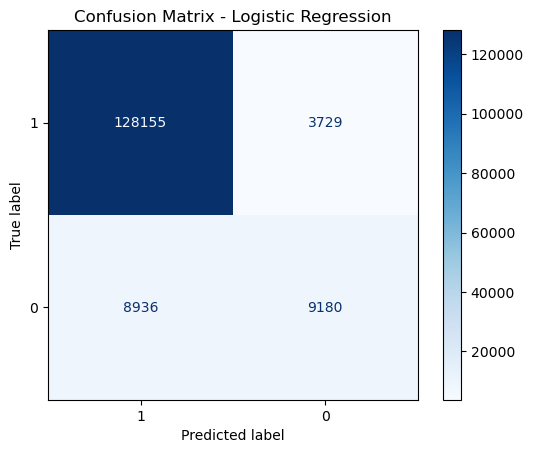

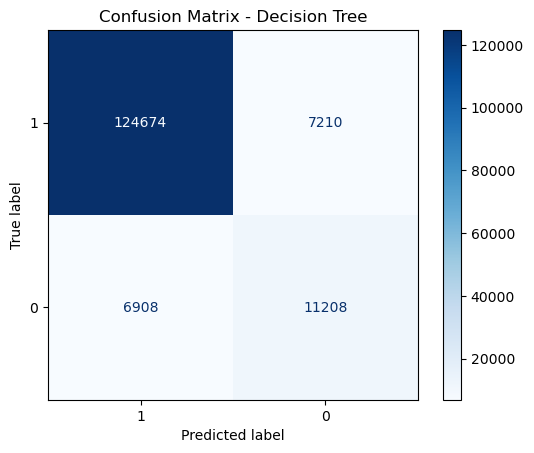

C:\Users\amour\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9188 - loss: 0.1840 - val_accuracy: 0.9269 - val_loss: 0.1657
Epoch 2/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9264 - loss: 0.1685 - val_accuracy: 0.9276 - val_loss: 0.1627
Epoch 3/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9282 - loss: 0.1652 - val_accuracy: 0.9301 - val_loss: 0.1604
Epoch 4/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9285 - loss: 0.1636 - val_accuracy: 0.9301 - val_loss: 0.1598
Epoch 5/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9290 - loss: 0.1625 - val_accuracy: 0.9303 - val_loss: 0.1589
Epoch 6/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9294 - loss: 0.1620 - val_accuracy: 0.9302 - val_loss: 0.1589
Epoch 7/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9299 - loss: 0.1615 - val_accuracy: 0.9308 - val_loss: 0.1584
Epoch 8/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9298 - loss: 0

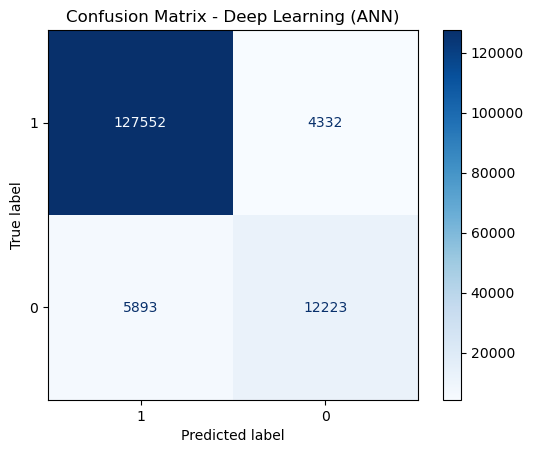


Model Performance Summary:

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.915567   0.711132  0.506734  0.591781
1        Decision Tree  0.905880   0.608535  0.618680  0.613565
2  Deep Learning (ANN)  0.931833   0.738327  0.674707  0.705085


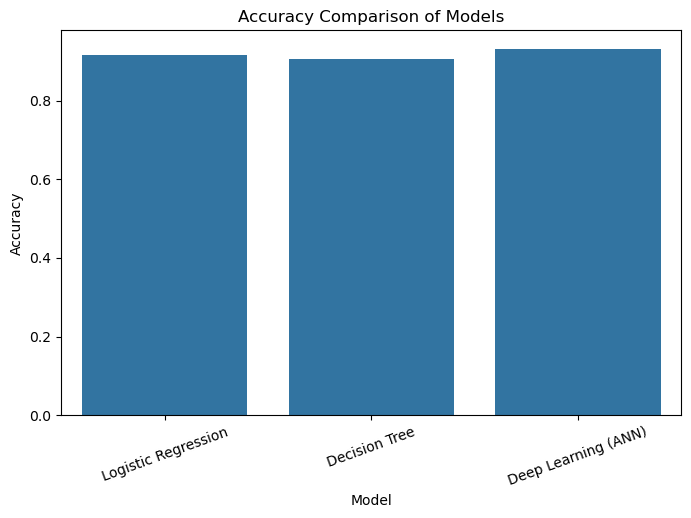

In [3]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import os

path = r"C:\Users\amour\OneDrive - University of Sharjah\amira 3rd year\AI\project\Bank_dataset\Bank_dataset"
os.chdir(path)

data = pd.read_csv('train.csv')    #reading the data file
print("Shape:", data.shape)  #describing data shape

X = data.iloc[:, 1:-1]   # all rows, all columns except the last and first
Y = data.iloc[:, -1]    # the last column is the target

print(data.isnull().sum())  # checking for missing values

categorical_features = X.select_dtypes(include=['object']).columns   #grouping categorical features
numeric_features = X.select_dtypes(exclude=['object']).columns    #grouping numerical features

ct = ColumnTransformer(
    transformers=[
        ( 'numerical' ,StandardScaler(), numeric_features),  # scale numbers
        ( 'string' ,OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)  # encode strings
    ],
    remainder='passthrough'
)

X = ct.fit_transform(X)
print(X)
X_train, X_test, y_train, y_test = train_test_split( X, Y, test_size=0.2, random_state= 0 )   #splitting the data into training and testing

# logistic regression model 
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)     #training logistic regression 
y_pred_lr = log_reg.predict(X_test)     #predicting logistic regression

cm_lr = confusion_matrix(y_test, y_pred_lr)     #creating the confusion matrix for logistic regression
ConfusionMatrixDisplay(cm_lr, display_labels=[1, 0]).plot(cmap='Blues')     #visualizing the confusion matrix for logistic regression
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# decision tree model 
dt = DecisionTreeClassifier(random_state=42, criterion='gini')   
dt.fit(X_train, y_train)   #training decision tree
y_pred_dt = dt.predict(X_test)   #predicting decision tree

cm_dt = confusion_matrix(y_test, y_pred_dt)  #creating the confusion matrix for decision tree
ConfusionMatrixDisplay(cm_dt, display_labels=[1, 0]).plot(cmap='Blues')    #visualizing the confusion matrix for decision tree
plt.title("Confusion Matrix - Decision Tree")
plt.show()

#Deep Learning (ANN) model (sequential)
# setting layers, dropout and relu activation and binary classification
model_dl = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

model_dl.compile(optimizer=Adam(learning_rate=0.001),   #compiling the model using adam optimization algorithm
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

#training the model
history = model_dl.fit(   
    X_train, y_train,  
    epochs=20, batch_size=128,      #the model passes throught the data 20 times, in batches of size 128
    validation_split=0.2, verbose=1   # 20% of the data is for validation 
)

y_pred_dl = (model_dl.predict(X_test) > 0.5).astype(int).flatten()  # predicting

cm_dl = confusion_matrix(y_test, y_pred_dl)
ConfusionMatrixDisplay(cm_dl, display_labels=[1, 0]).plot(cmap='Blues')   #creating the confusion matrix for ANN
plt.title("Confusion Matrix - Deep Learning (ANN)")   #visualizing the confusion matrix for ANN
plt.show()


#Results
results = pd.DataFrame([    #creating a dataset with results
    ["Logistic Regression",
     accuracy_score(y_test, y_pred_lr),
     precision_score(y_test, y_pred_lr),
     recall_score(y_test, y_pred_lr),
     f1_score(y_test, y_pred_lr)],

    ["Decision Tree",
     accuracy_score(y_test, y_pred_dt),
     precision_score(y_test, y_pred_dt),
     recall_score(y_test, y_pred_dt),
     f1_score(y_test, y_pred_dt)],

    ["Deep Learning (ANN)",
     accuracy_score(y_test, y_pred_dl),
     precision_score(y_test, y_pred_dl),
     recall_score(y_test, y_pred_dl),
     f1_score(y_test, y_pred_dl)]
],
columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
print("\nModel Performance Summary:\n")
print(results)

#plotting results
plt.figure(figsize=(8, 5))    
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Accuracy Comparison of Models")
plt.xticks(rotation=20)
plt.show()
